In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


In [2]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [3]:
def create_stego(images):
    stego_images = []

    for img in images:
        noise = np.random.randint(0, 10, img.shape, dtype=np.uint8)
        stego = np.clip(img + noise, 0, 255)
        stego_images.append(stego)

    return np.array(stego_images)

X_train_stego = create_stego(X_train)
X_test_stego = create_stego(X_test)

print("Stego created!")

Stego created!


In [4]:
# 0 = clean, 1 = stego

X_train_final = np.concatenate([X_train, X_train_stego])
y_train_final = np.concatenate([
    np.zeros(len(X_train)),
    np.ones(len(X_train_stego))
])

X_test_final = np.concatenate([X_test, X_test_stego])
y_test_final = np.concatenate([
    np.zeros(len(X_test)),
    np.ones(len(X_test_stego))
])

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

Final train shape: (100000, 32, 32, 3)
Final test shape: (20000, 32, 32, 3)


In [5]:
X_train_final = X_train_final / 255.0
X_test_final = X_test_final / 255.0

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))   # 👈 THIS IS NEW

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train_final,
    y_train_final,
    epochs=5,
    validation_data=(X_test_final, y_test_final)
)

Epoch 1/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 132s 42ms/step - accuracy: 0.7076 - loss: 0.5181 - val_accuracy: 0.6726 - val_loss: 0.5550
Epoch 2/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 141s 42ms/step - accuracy: 0.7348 - loss: 0.4654 - val_accuracy: 0.7409 - val_loss: 0.4454
Epoch 3/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 129s 41ms/step - accuracy: 0.7568 - loss: 0.4335 - val_accuracy: 0.7883 - val_loss: 0.3629
Epoch 4/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 144s 42ms/step - accuracy: 0.9001 - loss: 0.2297 - val_accuracy: 0.8547 - val_loss: 0.3251
Epoch 5/5
3125/3125 ━━━━━━━━━━━━━━━━━━━━ 131s 42ms/step - accuracy: 0.8102 - loss: 0.3645 - val_accuracy: 0.5513 - val_loss: 0.6635


625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step


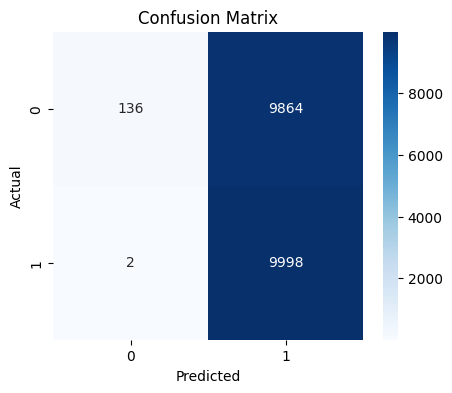

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test_final) > 0.3).astype("int32")

cm = confusion_matrix(y_test_final, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test_final, y_pred))

              precision    recall  f1-score   support

         0.0       0.53      0.98      0.69     10000
         1.0       0.87      0.12      0.21     10000

    accuracy                           0.55     20000
   macro avg       0.70      0.55      0.45     20000
weighted avg       0.70      0.55      0.45     20000

